In [19]:
import pandas as pd
import numpy as np
import pyarrow
from ml_utils.src import *
from ml_utils.config import *
import itertools
import gc 
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import  train_test_split
from sklearn.metrics import classification_report

import keras
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras import optimizers

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from keras.regularizers import l2


print(tf.config.list_physical_devices())
BATCH_SIZE = 64

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [4]:
import tensorflow as tf

tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

# 1.0 - Classificação de Presença Baseada em Fatores Socioeconômicos Usando Redes Neurais

In [2]:
colunas = ['Q001','Q002','Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 
           'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025', 'TP_PRESENCA_LC', 'TP_PRESENCA_CH', 'TP_PRESENCA_CN', 'TP_PRESENCA_MT', 
           'TP_FAIXA_ETARIA', 'TP_SEXO','TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_ESCOLA', 'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 
           'NU_ANO', 'TP_LOCALIZACAO_ESC','TP_SIT_FUNC_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_DEPENDENCIA_ADM_ESC']

df = pd.read_parquet(DATA_DIR, columns = colunas)

## 1.2- Pré-Processando os Dados

In [3]:
df = preparar_dados(df, objetivo = '', n_samples = 500_000)

## 1.3- Construção da Matriz X e Vetor y

In [5]:
X = df.drop([ 'FALTOU'], axis=1)

y = df['FALTOU']

## 1.4 - Separação em Dados de Treino, Validação e Teste

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

## 1.5 - Tratando os Dados

In [7]:
preprocessador = pre_processor(X_train)

X_train = preprocessador.transform(X_train).astype(np.float32)
X_val   = preprocessador.transform(X_val).astype(np.float32)
X_test  = preprocessador.transform(X_test).astype(np.float32)

In [8]:
max_neurons = num_max_neuronio(X_train, d = X_train.shape[1])
print("Número máximo de neurônios:", max_neurons)

Número máximo de neurônios: 197


## 1.6 - Estourando a Rede Neural

In [13]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(256, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(256, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(1, kernel_initializer='he_normal', activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,081 (305.00 KB)

 Trainable params: 78,081 (305.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [14]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=BATCH_SIZE)

Epoch 1/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7450 - loss: 0.5373 - val_accuracy: 0.7452 - val_loss: 0.5289
Epoch 2/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7494 - loss: 0.5262 - val_accuracy: 0.7473 - val_loss: 0.5339
Epoch 3/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7492 - loss: 0.5234 - val_accuracy: 0.7486 - val_loss: 0.5268
Epoch 4/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7505 - loss: 0.5220 - val_accuracy: 0.7474 - val_loss: 0.5250
Epoch 5/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7509 - loss: 0.5208 - val_accuracy: 0.7472 - val_loss: 0.5267
Epoch 6/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7515 - loss: 0.5197 - val_accuracy: 0.7467 - val_loss: 0.5248
Epoch 7/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7522 - loss: 0.5181 - val_accuracy: 0.7484 - val_loss: 0.5248
Epoch 8/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7533 - loss: 0

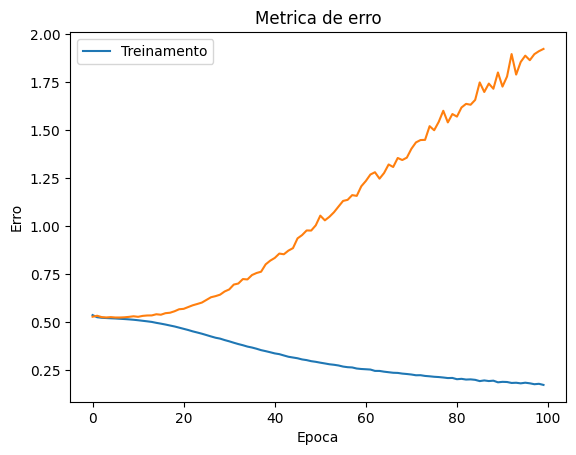


--> Acuracia (treino): 0.9320
--> Acuracia (val): 0.6752
--> E_val - E_in = 1.7616
--> acc_train - acc_val = 0.2568


In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento'])
plt.show()

E_in, acc_train = model.evaluate(X_train, y_train, batch_size=BATCH_SIZE, verbose=0)

E_val, acc_val = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f'\n--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (val): {acc_val:.4f}')
print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")

In [20]:
BATCH_SIZE = 64

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(256, kernel_initializer='he_normal', activation='relu',
          kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))

model.add(Dense(256, kernel_initializer='he_normal', activation='relu',
          kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))

model.add(Dense(1, kernel_initializer='he_normal', activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,081 (305.00 KB)

 Trainable params: 78,081 (305.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val) 
)

Epoch 1/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7335 - loss: 0.9395 - val_accuracy: 0.7432 - val_loss: 0.6683
Epoch 2/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7457 - loss: 0.5984 - val_accuracy: 0.7436 - val_loss: 0.5599
Epoch 3/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7459 - loss: 0.5521 - val_accuracy: 0.7453 - val_loss: 0.5412
Epoch 4/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7463 - loss: 0.5427 - val_accuracy: 0.7445 - val_loss: 0.5384
Epoch 5/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7462 - loss: 0.5405 - val_accuracy: 0.7457 - val_loss: 0.5506
Epoch 6/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7464 - loss: 0.5394 - val_accuracy: 0.7462 - val_loss: 0.5382
Epoch 7/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7459 - loss: 0.5390 - val_accuracy: 0.7458 - val_loss: 0.5384
Epoch 8/100
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7464 - loss: 0

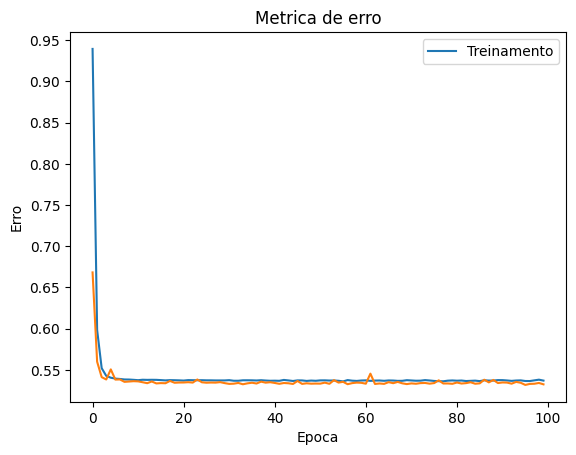


--> Acuracia (treino): 0.7495
--> Acuracia (val): 0.7462
--> E_val - E_in = 0.0031
--> acc_train - acc_val = 0.0033


In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento'])
plt.show()

E_in, acc_train = model.evaluate(X_train, y_train, batch_size=BATCH_SIZE, verbose=0)

E_val, acc_val = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f'\n--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (val): {acc_val:.4f}')
print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")

## 1.7 - Treinando a Rede Neural com melhores parâmetros

In [24]:
param_grid = {
    'neurons':       [max_neurons - 1],
    'learning_rate': [0.01, 0.001, 0.0001],   
    'batch_size':    [64],             
    'epochs':        [100],
    'l2_reg':        [0.001, 0.01, 0.1],          
    'dropout':       [0.0, 0.2],
}

keys, values = zip(*param_grid.items())
combinacoes = [dict(zip(keys, v)) for v in itertools.product(*values)]
print(f"Total de combinações: {len(combinacoes)}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = []

for params in combinacoes:
    print(f"Testando: {params}")
    
    accs = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        classes = np.unique(y_tr)
        weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=y_tr
        )

        class_weight = dict(zip(classes, weights))
        model = create_model(
            input_dim=X_train.shape[1],
            neurons=params['neurons'],
            learning_rate=params['learning_rate'],
            l2_reg=params['l2_reg'],
            dropout=params['dropout']
        )

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val_fold, y_val_fold),
            epochs=params['epochs'],
            batch_size=params['batch_size'],
            callbacks=[early_stop],
            class_weight=class_weight,
            verbose=1
        )

        loss, acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
        accs.append(acc)

        del model
        gc.collect()

    mean_acc = np.mean(accs)

    resultados.append({
        'params': params,
        'mean_accuracy': mean_acc
    })

    print(f"Accuracy média: {mean_acc:.4f}")

Total de combinações: 18
Testando: {'neurons': 196, 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 100, 'l2_reg': 0.001, 'dropout': 0.0}
Epoch 1/100
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6145 - loss: 0.6789 - val_accuracy: 0.6951 - val_loss: 0.5935
Epoch 2/100
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6222 - loss: 0.6395 - val_accuracy: 0.5767 - val_loss: 0.6760
Epoch 3/100
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6229 - loss: 0.6372 - val_accuracy: 0.6597 - val_loss: 0.6185
Epoch 4/100
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6243 - loss: 0.6355 - val_accuracy: 0.6385 - val_loss: 0.6280
Epoch 5/100
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6236 - loss: 0.6355 - val_accuracy: 0.6337 - val_loss: 0.6261
Epoch 6/100
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6281 - loss: 0.6339 - val_accuracy: 0.7142 - val_loss: 0.5736
Epoch 7/100
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6274

### Salvando os resultados

In [25]:
resultados_df = pd.DataFrame(resultados)
resultados_df = resultados_df.sort_values(by='mean_accuracy', ascending=False)

In [26]:
resultados_df.to_csv("resultados_presenca_socioeconomicos.csv", index=False)

In [30]:
resultados_df.params[0]

{'neurons': 196,
 'learning_rate': 0.01,
 'batch_size': 64,
 'epochs': 100,
 'l2_reg': 0.001,
 'dropout': 0.0}

## 1.8 - Treinando com todos os dados de treino

In [27]:
X = df.drop(columns=['FALTOU'])
y = df['FALTOU']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
preprocessador = pre_processor(X_train)

X_train = preprocessador.transform(X_train).astype(np.float32)
X_test  = preprocessador.transform(X_test).astype(np.float32)

In [36]:
adam = Adam(learning_rate=0.01)

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(196, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.001), 
                activation='relu'))

model.add(Dense(1, kernel_initializer='he_normal', activation='sigmoid'))

# Compilar o modelo
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

print(model.summary())

Model: "sequential_108"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_222 (Dense)               │ (None, 196)            │         9,212 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_223 (Dense)               │ (None, 1)              │           197 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,409 (36.75 KB)

 Trainable params: 9,409 (36.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [37]:
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=BATCH_SIZE,
                    class_weight=class_weight) 

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(X_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de teste
E_test, acc_test = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)

print(f"--> E_test - E_in = {E_test - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (teste): {acc_test:.4f}')
print(f"--> acc_train - acc_test = {acc_train - acc_test:.4f}")

Epoch 1/100
1857/1857 ━━━━━━━━━━━━━━━━━━━━ 2s 921us/step - accuracy: 0.6184 - loss: 0.6624
Epoch 2/100
1857/1857 ━━━━━━━━━━━━━━━━━━━━ 2s 905us/step - accuracy: 0.6238 - loss: 0.6363
Epoch 3/100
1857/1857 ━━━━━━━━━━━━━━━━━━━━ 2s 911us/step - accuracy: 0.6248 - loss: 0.6351
Epoch 4/100
1857/1857 ━━━━━━━━━━━━━━━━━━━━ 2s 859us/step - accuracy: 0.6267 - loss: 0.6341
Epoch 5/100
1857/1857 ━━━━━━━━━━━━━━━━━━━━ 2s 848us/step - accuracy: 0.6281 - loss: 0.6334
Epoch 6/100
1857/1857 ━━━━━━━━━━━━━━━━━━━━ 2s 902us/step - accuracy: 0.6283 - loss: 0.6339
Epoch 7/100
1857/1857 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6280 - loss: 0.6336
Epoch 8/100
1857/1857 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6278 - loss: 0.6338
Epoch 9/100
1857/1857 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6302 - loss: 0.6325  
Epoch 10/100
1857/1857 ━━━━━━━━━━━━━━━━━━━━ 2s 928us/step - accuracy: 0.6297 - loss: 0.6328
Epoch 11/100
1857/1857 ━━━━━━━━━━━━━━━━━━━━ 2s 949us/step - accuracy: 0.6288 - loss: 0.6328
E

In [38]:
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred))

929/929 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step
              precision    recall  f1-score   support

           0       0.84      0.61      0.71     21865
           1       0.38      0.68      0.49      7838

    accuracy                           0.63     29703
   macro avg       0.61      0.64      0.60     29703
weighted avg       0.72      0.63      0.65     29703

